In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.shape

(119390, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [10]:
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)
df["children"] = df["children"].fillna(0)

In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [14]:
df['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [15]:
df["arrival_date"] = pd.to_datetime(df["arrival_date_year"].astype(str)+ "-"+ df["arrival_date_month"]+ "-"+ df["arrival_date_day_of_month"].astype(str))

In [16]:
df[["arrival_date_year", "arrival_date_month","arrival_date_day_of_month","arrival_date"]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


In [17]:
df["arrival_date"].dtype

dtype('<M8[ns]')

In [18]:
month_order = ["January", "February", "March", "April","May", "June", "July", "August","September", "October", "November", "December"]

In [19]:
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],categories=month_order,ordered=True)

In [22]:
booking_pivot = pd.pivot_table(df,index="arrival_date_month",columns="hotel", values="arrival_date",aggfunc="count",observed=False)

In [23]:
booking_pivot

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,3736,2193
February,4965,3103
March,6458,3336
April,7480,3609
May,8232,3559
June,7894,3045
July,8088,4573
August,8983,4894
September,7400,3108


### Seasonal Demand Interpretation

The pivot table shows a clear seasonal pattern in hotel booking demand.

August records the highest total booking volume with 13,877 bookings across both hotel types, while January has the lowest volume with 5,929 bookings.

City Hotel has a higher booking volume than Resort Hotel in every month. However, Resort Hotel demand increases notably during the summer months, reaching its highest level in August with 4,894 bookings.

This suggests stronger seasonal demand for Resort Hotels during the summer period, while City Hotels maintain higher overall booking volume throughout the year.

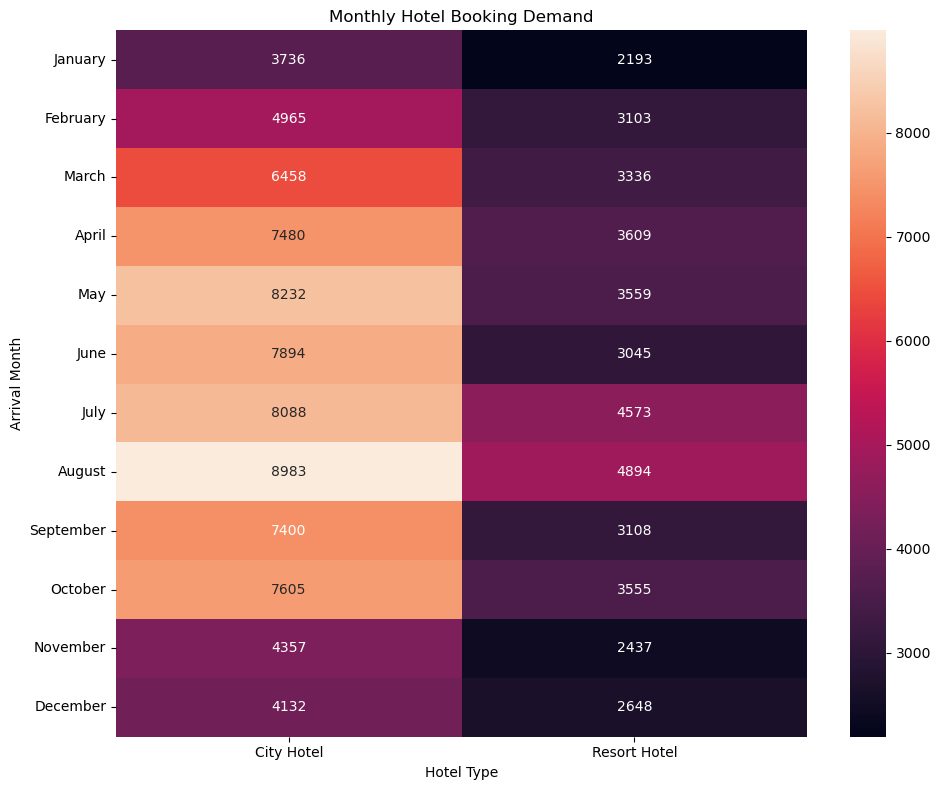

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(booking_pivot, annot = True , fmt = ".0f")

plt.title("Monthly Hotel Booking Demand")
plt.xlabel("Hotel Type")
plt.ylabel("Arrival Month")

plt.tight_layout()

plt.savefig("booking_heatmap.png",dpi=300,bbox_inches="tight")

plt.show()

In [30]:
monthly_cancellation = (df.groupby(['arrival_date_month', 'hotel'], observed = False )['is_canceled'].mean().reset_index().round(3))

monthly_cancellation["cancellation_rate"] = (monthly_cancellation["is_canceled"] * 100).round(3)

monthly_cancellation

,arrival_date_month,hotel,is_canceled,cancellation_rate
0,January,City Hotel,0.397,39.7
1,January,Resort Hotel,0.148,14.8
2,February,City Hotel,0.383,38.3
3,February,Resort Hotel,0.256,25.6
4,March,City Hotel,0.369,36.9
5,March,Resort Hotel,0.229,22.9
6,April,City Hotel,0.463,46.3
7,April,Resort Hotel,0.293,29.3
8,May,City Hotel,0.444,44.4
9,May,Resort Hotel,0.288,28.8


### Monthly Cancellation Rate

City Hotel has a higher cancellation rate than Resort Hotel in every month. City Hotel's cancellation rate ranges from 36.9% to 46.3%, while Resort Hotel's rate ranges from 14.8% to 33.4%.

The highest cancellation rate for City Hotel occurs in April at 46.3%. For Resort Hotel, the highest rate occurs in August at 33.4%.

The consistently higher cancellation rate at City Hotel indicates greater booking uncertainty and may require stronger cancellation-management.

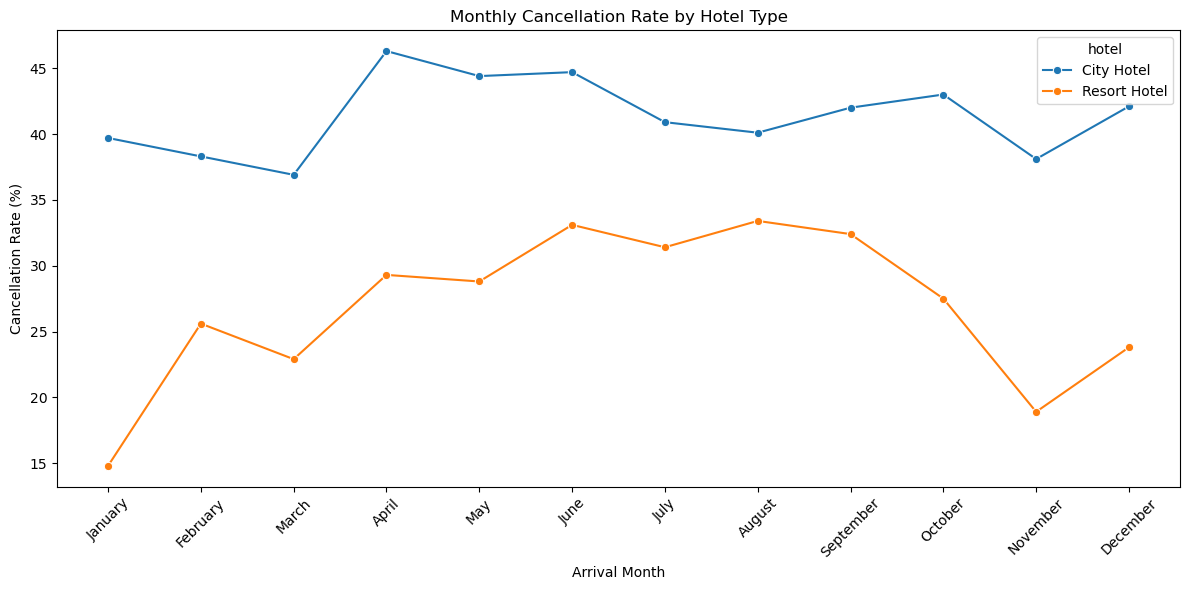

In [31]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=monthly_cancellation, x="arrival_date_month", y="cancellation_rate", hue="hotel",marker="o")

plt.title("Monthly Cancellation Rate by Hotel Type")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("cancellation_rate.png",dpi=300, bbox_inches="tight")

plt.show()

In [32]:
lead_time_comparison = (df.groupby("is_canceled")['lead_time'].mean().reset_index())
lead_time_comparison["booking_status"] = (lead_time_comparison["is_canceled"].map({0: "Not Canceled",1: "Canceled"}))
lead_time_comparison

,is_canceled,lead_time,booking_status
0,0,79.984687,Not Canceled
1,1,144.848815,Canceled



### Lead Time and Cancellation

Cancelled bookings had an average lead time of 144.85 days, compared with 79.98 days for bookings that were not cancelled.

Therefore, cancelled bookings were made approximately 64.87 days earlier on average. This indicates an association between longer booking lead times and cancellation behavior.

In [37]:
country_analysis = (df.groupby("country").agg(total_bookings=("country", "size"),cancellation_rate=("is_canceled", "mean")).reset_index())

country_analysis["cancellation_rate"] = (country_analysis["cancellation_rate"] * 100).round(2)

In [38]:
top_10_countries = (country_analysis.sort_values("total_bookings", ascending=False).head(10))
top_10_countries

,country,total_bookings,cancellation_rate
135,PRT,48590,56.64
59,GBR,12129,20.22
56,FRA,10415,18.57
51,ESP,8568,25.41
43,DEU,7287,16.71
81,ITA,3766,35.40
76,IRL,3375,24.65
15,BEL,2342,20.24
25,BRA,2224,37.32
123,NLD,2104,18.39


### Top 10 Countries by Booking Volume

Portugal (PRT) has the highest number of bookings with 48,590 reservations and a cancellation rate of 56.64%. The United Kingdom (GBR) is the second-largest market with 12,129 bookings and a cancellation rate of 20.22%.

Among the top 10 countries, Germany (16.71%) has the lowest cancellation rate, while Portugal (56.64%) has the highest.

These differences show that booking volume and cancellation behavior vary substantially across source markets. The results can help revenue managers identify markets where cancellation risk should be considered when forecasting demand.

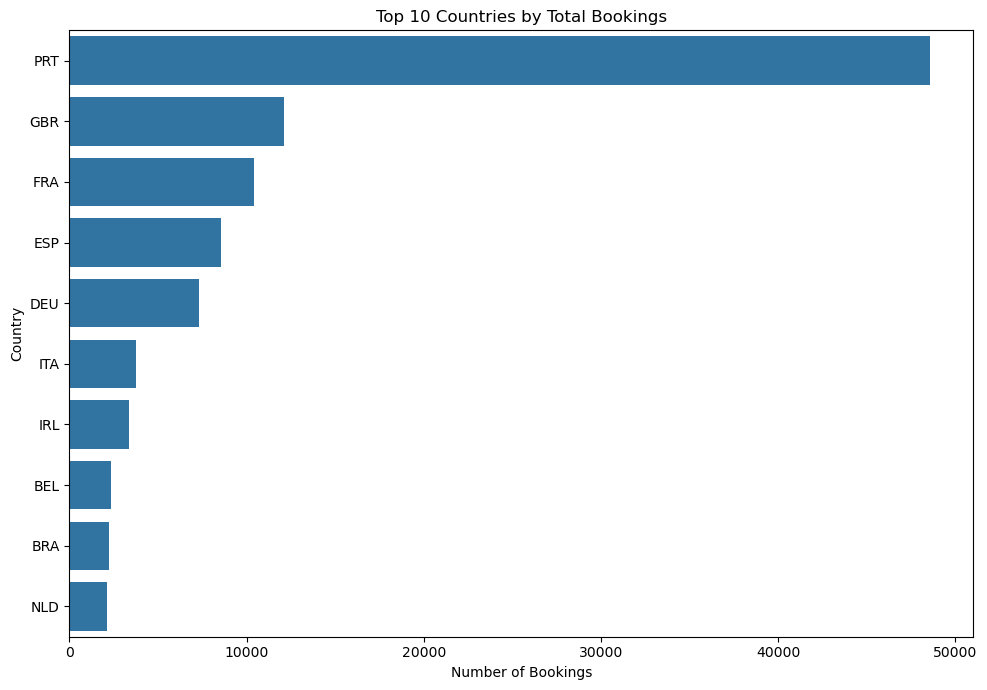

In [39]:
plt.figure(figsize = (10,7))

sns.barplot(data = top_10_countries, x = "total_bookings", y = "country")

plt.title("Top 10 Countries by Total Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("top_10_countries.png", dpi=300,bbox_inches="tight")

plt.show()

In [43]:
market_segment_analysis = (df.groupby("market_segment").agg(total_bookings = ("market_segment", "size"), cancelled_booking = ("is_canceled", "sum"), cancellation_rate = ("is_canceled", "mean")).reset_index())

market_segment_analysis["cancellation_rate"] = (market_segment_analysis["cancellation_rate"] * 100)

market_segment_analysis = market_segment_analysis.sort_values("total_bookings",ascending=False)

market_segment_analysis

,market_segment,total_bookings,cancelled_booking,cancellation_rate
6,Online TA,56477,20739,36.721143
5,Offline TA/TO,24219,8311,34.316033
4,Groups,19811,12097,61.062036
3,Direct,12606,1934,15.341901
2,Corporate,5295,992,18.734655
1,Complementary,743,97,13.055182
0,Aviation,237,52,21.940928
7,Undefined,2,2,100.000000


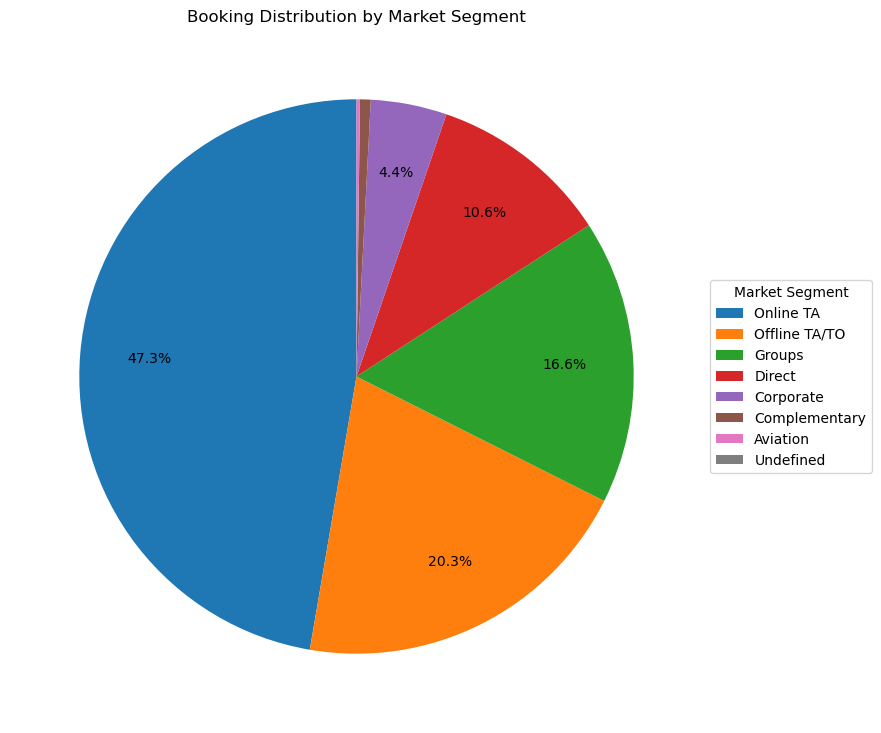

In [56]:
plt.figure(figsize=(9, 9))

plt.pie(market_segment_analysis["total_bookings"], labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",startangle=90, pctdistance=0.75)

plt.legend(market_segment_analysis["market_segment"],title="Market Segment",loc="center left",bbox_to_anchor=(1, 0.5))

plt.title("Booking Distribution by Market Segment")

plt.savefig("market_segment.png",dpi=300,bbox_inches="tight")

plt.show()

### Market Segment Analysis

Online TA is the largest market segment, accounting for 56,477 bookings, or approximately 47.3% of all bookings. Offline TA/TO is the second-largest segment with 24,219 bookings, representing 20.3% of total bookings. Groups account for 19,811 bookings (16.6%), while Direct bookings account for 12,606 bookings (10.6%).
The Groups segment has the highest cancellation rate among the major market segments at 61.06%. Online TA has a cancellation rate of 36.72%, while Offline TA/TO has a rate of 34.32%. Direct bookings have a lower cancellation rate of 15.34%.
The Complementary segment has the lowest cancellation rate at 13.06%, although it contains only 743 bookings. The Undefined segment has a 100% cancellation rate, but this is based on only two bookings and should not be interpreted as a meaningful pattern.
Overall, the results show that booking volume and cancellation risk vary considerably across market segments. Revenue managers can use both measures when evaluating demand and managing cancellation risk.

In [46]:
adr_by_month = (df.groupby(["arrival_date_month", "hotel"],observed=False)["adr"].mean().reset_index())
adr_by_month

,arrival_date_month,hotel,adr
0,January,City Hotel,82.628986
1,January,Resort Hotel,49.461883
2,February,City Hotel,85.088278
3,February,Resort Hotel,55.171930
4,March,City Hotel,92.643116
5,March,Resort Hotel,57.520147
6,April,City Hotel,111.251838
7,April,Resort Hotel,77.849496
8,May,City Hotel,121.638560
9,May,Resort Hotel,78.758134


In [48]:
adr_pivot = adr_by_month.pivot(index="arrival_date_month",columns="hotel",values="adr")
adr_pivot

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,82.628986,49.461883
February,85.088278,55.171930
March,92.643116,57.520147
April,111.251838,77.849496
May,121.638560,78.758134
June,119.074341,110.444749
July,110.734292,155.181299
August,114.680455,186.790574
September,110.004661,93.252030


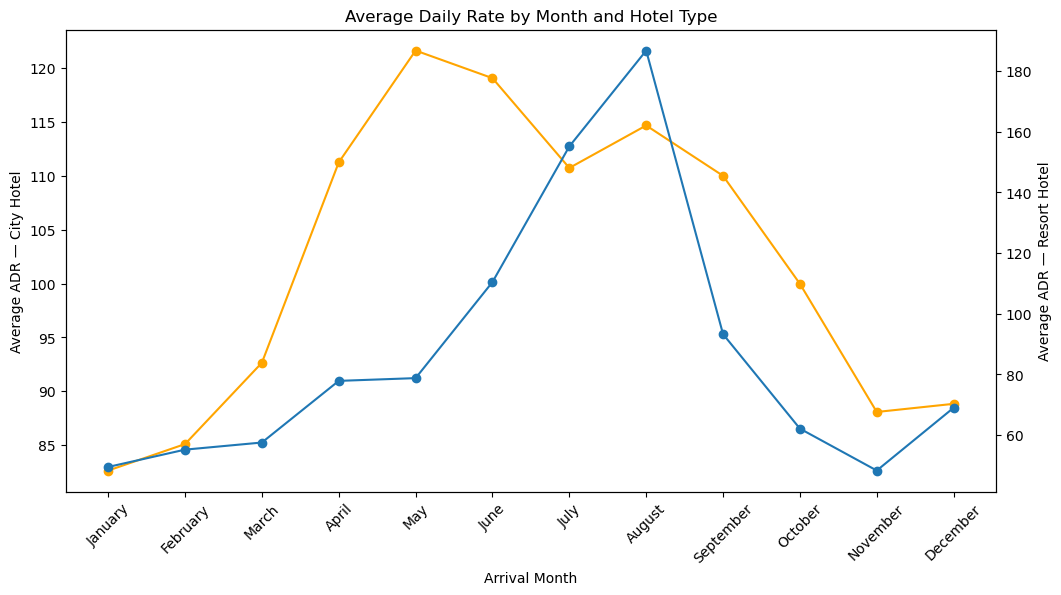

In [54]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(adr_pivot.index, adr_pivot["City Hotel"],marker="o", label="City Hotel", color = "orange")

ax1.set_xlabel("Arrival Month")
ax1.set_ylabel("Average ADR — City Hotel")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(adr_pivot.index,adr_pivot["Resort Hotel"],marker="o",label="Resort Hotel")

ax2.set_ylabel("Average ADR — Resort Hotel")
plt.title("Average Daily Rate by Month and Hotel Type")
plt.savefig( "adr_by_month.png",dpi=300,bbox_inches="tight")

plt.show()

## Business Insights

1. **Strong seasonal demand**
   
   August is the peak booking month, with 13,877 total bookings across City Hotel and Resort Hotel. January has the lowest demand with 5,929 bookings. Revenue managers can use seasonal pricing and promotional strategies to respond to these demand differences.

2. **City Hotel has higher cancellation risk**
   
   City Hotel has a higher cancellation rate than Resort Hotel in every month. Its highest monthly cancellation rate is 46.3% in April. This suggests that cancellation risk should be considered when forecasting occupancy and expected revenue.

3. **Longer lead times are associated with cancellations**
   
   Cancelled bookings have an average lead time of 144.85 days, compared with 79.98 days for non-cancelled bookings. This difference suggests that bookings made further in advance are associated with higher cancellation risk and may require closer monitoring.

4. **Market segments differ in both demand and cancellation behavior**
   
   Online TA is the largest market segment, representing 47.3% of all bookings. However, the Groups segment has a much higher cancellation rate of 61.06%. Revenue managers should therefore consider both booking volume and cancellation risk when managing different market segments.